# Nonconforming LCG MMS convergence - 2D point trace

This notebook solves the nonconforming MMS fracture problem with an independent 1D fracture mesh and point-trace coupling to the 2D bulk.  It now also performs a rectangular Deng-style locally conservative post-processing of the bulk pressure.

Default setup: P2 bulk/fracture pressure spaces with a coarse DG0/P0 multiplier (`h_lambda ~= 2h`).  The convergence tables report pressure/flux errors before and after reconstruction, plus fracture-pressure, multiplier, jump, and local-conservation residual diagnostics.


> **⚠️ Note to self — this notebook is FEM-only. There is NO PINN here, despite the filename.**

The name `LCG_nonconforming_PINN_flux_reconstruction_MMS_2d_no_fenicsx_ii.ipynb` was inherited from the
template it was copied/named after. The content has **always** been a pure-FEM convergence study:
independent 1D fracture mesh, 2D point-trace coupling to the 2D bulk, and a rectangular Deng-style
locally conservative post-processing of the bulk pressure. No neural network / `torch` / training
is part of this notebook.

**Verified 2026-06-14 across every recovery source** — git (all blobs, full history), VS Code Local
History (44 snapshots going back to the first save on 2026-06-02), Jupyter checkpoints, `.bak`/swap
files, the XDG Trash, and the Windows drives. A PINN version *under this filename* **never existed**,
so there is nothing to "recover": this file was not overwritten from a lost PINN notebook.

The real PINN notebooks (neural flux model + training, sections 0–13) are intact elsewhere:
- `LCG_nonconforming_PINN_flux_reconstruction_MMS.ipynb` — reference, full 13-section PINN pipeline
- `LCG_nonconforming_PINN_flux_reconstruction_KoppelMartin_case1_2d.ipynb` — 2D PINN variant

In [1]:
from mpi4py import MPI
from petsc4py import PETSc
import pathlib
import time

import numpy as np
import matplotlib.pyplot as plt
import ufl
import basix.ufl
from dolfinx import fem, mesh

comm = MPI.COMM_WORLD
rank = comm.rank
if comm.size != 1:
    raise RuntimeError("This manual point-trace assembly notebook is serial; run it with one MPI rank.")

# Convergence controls.
RUN_CONVERGENCE = True
CONV_REFS = [ 2, 3, 4, 5, 6 ]
CONV_TIP_FRAC = 0.1
CONV_PLOT = True

# P1/P0 standard rectangular Deng setup.
# h_Gamma ~= h/2 and h_lambda ~= 2h.
# The current full-diagonal point-trace P0 solve is stable through ref=3; ref>=4 needs a separate inf-sup/conditioning fix.
PRESSURE_ORDER = 1
MULTIPLIER_ORDER = 0
FEM_ORDER = PRESSURE_ORDER  # Backward-compatible alias if later cells are added.

# Alternative Koppel-Martin-style low-order check:
# PRESSURE_ORDER = 1
# MULTIPLIER_ORDER = 0
# FRACTURE_PRESSURE_LC_FACTOR = 0.5
# MULTIPLIER_LC_FACTOR = 2.0

# MMS parameters.
ALPHA = 1.0
K_M_VALUE = 1.0
K_F_VALUE = 100.0

# Full diagonal MMS fracture, matching the nonconforming MMS notebook.
FRAC_A = np.array([0.0, 0.0], dtype=float)
FRAC_B = np.array([1.0, 1.0], dtype=float)
TIP_FRAC = CONV_TIP_FRAC

# Independent fracture and multiplier mesh sizes.
FRACTURE_PRESSURE_LC_FACTOR = 0.5
MULTIPLIER_LC_FACTOR = 3.0

OUTDIR = pathlib.Path("fracture_problem_nonconforming_mms_2d_no_fenicsx_ii")
OUTDIR.mkdir(parents=True, exist_ok=True)


In [2]:
def unit(v):
    v = np.asarray(v, dtype=float)
    nrm = np.linalg.norm(v)
    if nrm == 0.0:
        raise ValueError("zero-length vector")
    return v / nrm


tau_np = unit(FRAC_B - FRAC_A)
normal_np = np.array([-tau_np[1], tau_np[0]], dtype=float)
L_gamma = float(np.linalg.norm(FRAC_B - FRAC_A))


def real_points_np(s):
    s = np.asarray(s, dtype=float).reshape(-1)
    return FRAC_A[None, :] + s[:, None] * tau_np[None, :]


def signed_distance_np(points):
    return (np.asarray(points, dtype=float)[:, :2] - FRAC_A) @ normal_np


def s_coord_np(points):
    return (np.asarray(points, dtype=float)[:, :2] - FRAC_A) @ tau_np


def q_exact_xy(x, y):
    return np.sin(np.pi * x) * np.sin(np.pi * y)


def r_exact_xy(x, y):
    return normal_np[0] * (x - FRAC_A[0]) + normal_np[1] * (y - FRAC_A[1])


def p_m_exact_xy(x, y):
    q = q_exact_xy(x, y)
    return q + ALPHA * np.abs(r_exact_xy(x, y)) * q


def p_gamma_exact_xy(x, y):
    return q_exact_xy(x, y)


def lambda_exact_xy(x, y):
    return -2.0 * ALPHA * q_exact_xy(x, y)



def grad_q_exact_xy(x, y):
    return np.column_stack([
        np.pi * np.cos(np.pi * x) * np.sin(np.pi * y),
        np.pi * np.sin(np.pi * x) * np.cos(np.pi * y),
    ])


def exact_grad_p(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    x = pts[:, 0]
    y = pts[:, 1]
    q = q_exact_xy(x, y)
    grad_q = grad_q_exact_xy(x, y)
    r = r_exact_xy(x, y)
    sign_r = np.where(r >= 0.0, 1.0, -1.0)
    return grad_q + ALPHA * (
        sign_r[:, None] * normal_np[None, :] * q[:, None]
        + np.abs(r)[:, None] * grad_q
    )


def exact_q(points):
    return -K_M_VALUE * exact_grad_p(points)


def exact_dp_gamma_ds(s):
    pts = real_points_np(s)
    grad_q = grad_q_exact_xy(pts[:, 0], pts[:, 1])
    return grad_q @ tau_np


def f_m_exact_xy(x, y):
    q = q_exact_xy(x, y)
    r = r_exact_xy(x, y)
    sign_r = np.where(r >= 0.0, 1.0, -1.0)
    n_dot_grad_q = (
        normal_np[0] * np.pi * np.cos(np.pi * x) * np.sin(np.pi * y)
        + normal_np[1] * np.pi * np.sin(np.pi * x) * np.cos(np.pi * y)
    )
    return K_M_VALUE * (
        2.0 * np.pi**2 * q
        + 2.0 * ALPHA * np.pi**2 * np.abs(r) * q
        - 2.0 * ALPHA * sign_r * n_dot_grad_q
    )


def f_gamma_exact_xy(x, y):
    qg = q_exact_xy(x, y)
    d2_q_ds2 = (
        -np.pi**2 * qg
        + 2.0 * np.pi**2 * tau_np[0] * tau_np[1]
        * np.cos(np.pi * x) * np.cos(np.pi * y)
    )
    return -K_F_VALUE * d2_q_ds2 + lambda_exact_xy(x, y)


def estimate_bulk_h(omega):
    coords = omega.geometry.x

    def min_positive_spacing(values):
        vals = np.unique(np.round(np.sort(values), 14))
        diffs = np.diff(vals)
        diffs = diffs[diffs > 1.0e-12]
        return float(diffs.min()) if diffs.size else np.inf

    return min(min_positive_spacing(coords[:, 0]), min_positive_spacing(coords[:, 1]))


def make_line_mesh_from_s_nodes(s_nodes):
    s_nodes = np.asarray(s_nodes, dtype=float)
    nodes = real_points_np(s_nodes)
    n_cells = len(s_nodes) - 1
    cells = np.column_stack([np.arange(n_cells), np.arange(1, n_cells + 1)]).astype(np.int64)
    coord_el = ufl.Mesh(basix.ufl.element("Lagrange", basix.CellType.interval, 1, shape=(2,)))
    try:
        gamma_mesh = mesh.create_mesh(comm, cells, coord_el, nodes)
    except (TypeError, AttributeError, IndexError):
        gamma_mesh = mesh.create_mesh(comm, cells, nodes, coord_el)
    return gamma_mesh, float(np.max(np.diff(s_nodes))), int(n_cells), s_nodes


def make_fracture_meshes(h):
    h_gamma_target = FRACTURE_PRESSURE_LC_FACTOR * h
    h_lambda_target = MULTIPLIER_LC_FACTOR * h
    n_gamma = max(1, int(np.ceil(L_gamma / h_gamma_target)))
    n_lambda = max(1, int(np.ceil(L_gamma / h_lambda_target)))
    s_gamma = np.linspace(0.0, L_gamma, n_gamma + 1)
    s_lambda = np.linspace(0.0, L_gamma, n_lambda + 1)
    gamma, h_gamma, n_gamma, _ = make_line_mesh_from_s_nodes(s_gamma)
    gamma_l, h_lambda, n_lambda, _ = make_line_mesh_from_s_nodes(s_lambda)
    return gamma, gamma_l, h_gamma, h_lambda, n_gamma, n_lambda


def make_nonconforming_meshes(ref):
    n_bulk = 2 ** (ref + 1)
    omega = mesh.create_unit_square(comm, n_bulk, n_bulk, cell_type=mesh.CellType.quadrilateral)
    h = estimate_bulk_h(omega)
    gamma, gamma_l, h_gamma, h_lambda, n_gamma, n_lambda = make_fracture_meshes(h)
    return omega, gamma, gamma_l, h, h_gamma, h_lambda, n_bulk, n_gamma, n_lambda


def gauss_interval(n):
    x, w = np.polynomial.legendre.leggauss(int(n))
    return 0.5 * (x + 1.0), 0.5 * w


_GB, _WB = gauss_interval(8)
_GL, _WL = gauss_interval(10)


def quad_points_weights():
    pts, weights = [], []
    for i, xi in enumerate(_GB):
        for j, eta in enumerate(_GB):
            pts.append([xi, eta])
            weights.append(_WB[i] * _WB[j])
    return np.asarray(pts, dtype=float), np.asarray(weights, dtype=float)


def _space_ndofs(V):
    return int(V.dofmap.index_map.size_global * V.dofmap.index_map_bs)


In [3]:
def lagrange_1d_values_and_derivatives(nodes, x):
    nodes = np.asarray(nodes, dtype=float).reshape(-1)
    x = np.asarray(x, dtype=float).reshape(-1)
    n = len(nodes)
    vals = np.ones((x.size, n), dtype=float)
    ders = np.zeros((x.size, n), dtype=float)
    if n == 1:
        return vals, ders

    for i in range(n):
        for j in range(n):
            if j != i:
                vals[:, i] *= (x - nodes[j]) / (nodes[i] - nodes[j])
        for k in range(n):
            if k == i:
                continue
            term = np.ones_like(x) / (nodes[i] - nodes[k])
            for j in range(n):
                if j != i and j != k:
                    term *= (x - nodes[j]) / (nodes[i] - nodes[j])
            ders[:, i] += term
    return vals, ders


def polygon_signed_area(poly):
    x = poly[:, 0]
    y = poly[:, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)


def order_polygon_vertices(pts):
    pts = np.asarray(pts, dtype=float)
    ctr = pts.mean(axis=0)
    ang = np.arctan2(pts[:, 1] - ctr[1], pts[:, 0] - ctr[0])
    poly = pts[np.argsort(ang)]
    if polygon_signed_area(poly) < 0:
        poly = poly[::-1]
    return poly


def build_bulk_cell_data(omega, V_m, n_bulk):
    tdim = omega.topology.dim
    omega.topology.create_connectivity(tdim, 0)
    c2v = omega.topology.connectivity(tdim, 0)
    dof_coords = V_m.tabulate_dof_coordinates()[:, :2]
    geom = omega.geometry.x[:, :2]
    h = 1.0 / n_bulk
    cells = []
    lookup = {}
    num_cells = omega.topology.index_map(tdim).size_local
    for ci in range(num_cells):
        verts = np.asarray(c2v.links(ci), dtype=np.int32)
        poly = order_polygon_vertices(geom[verts])
        x0, y0 = poly.min(axis=0)
        x1, y1 = poly.max(axis=0)
        dofs = np.asarray(V_m.dofmap.cell_dofs(ci), dtype=np.int32)
        dof_xy = dof_coords[dofs]
        xi_nodes = np.unique(np.round((dof_xy[:, 0] - x0) / (x1 - x0), 14))
        eta_nodes = np.unique(np.round((dof_xy[:, 1] - y0) / (y1 - y0), 14))
        cell = {
            "cell_id": int(ci),
            "dofs": dofs,
            "dof_xy": dof_xy,
            "poly": poly,
            "x0": float(x0),
            "x1": float(x1),
            "y0": float(y0),
            "y1": float(y1),
            "hx": float(x1 - x0),
            "hy": float(y1 - y0),
            "xi_nodes": xi_nodes,
            "eta_nodes": eta_nodes,
            "dof_xi_idx": np.searchsorted(xi_nodes, np.round((dof_xy[:, 0] - x0) / (x1 - x0), 14)),
            "dof_eta_idx": np.searchsorted(eta_nodes, np.round((dof_xy[:, 1] - y0) / (y1 - y0), 14)),
            "centroid": np.array([0.5 * (x0 + x1), 0.5 * (y0 + y1)], dtype=float),
        }
        cells.append(cell)
        ix = int(round(x0 / h))
        iy = int(round(y0 / h))
        lookup[(ix, iy)] = int(ci)
    return {"cells": cells, "lookup": lookup, "n_bulk": int(n_bulk), "h": float(h)}


def locate_bulk_cell_xy(pt, bulk_data):
    x, y = np.asarray(pt, dtype=float)[:2]
    n = bulk_data["n_bulk"]
    h = bulk_data["h"]
    tol = 1.0e-12
    ix = n - 1 if x >= 1.0 - tol else int(np.floor(max(x, 0.0) / h))
    iy = n - 1 if y >= 1.0 - tol else int(np.floor(max(y, 0.0) / h))
    ix = min(max(ix, 0), n - 1)
    iy = min(max(iy, 0), n - 1)
    return bulk_data["cells"][bulk_data["lookup"][(ix, iy)]]


def quad_lagrange_values_grads_on_cell(cell, points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    xi = (pts[:, 0] - cell["x0"]) / cell["hx"]
    eta = (pts[:, 1] - cell["y0"]) / cell["hy"]
    Lx, dLx = lagrange_1d_values_and_derivatives(cell["xi_nodes"], xi)
    Ly, dLy = lagrange_1d_values_and_derivatives(cell["eta_nodes"], eta)
    nd = len(cell["dofs"])
    vals = np.zeros((pts.shape[0], nd), dtype=float)
    grads = np.zeros((pts.shape[0], nd, 2), dtype=float)
    for a in range(nd):
        ix = cell["dof_xi_idx"][a]
        iy = cell["dof_eta_idx"][a]
        vals[:, a] = Lx[:, ix] * Ly[:, iy]
        grads[:, a, 0] = (dLx[:, ix] / cell["hx"]) * Ly[:, iy]
        grads[:, a, 1] = Lx[:, ix] * (dLy[:, iy] / cell["hy"])
    return vals, grads


def bulk_breakpoints_on_segment(xa, xb, bulk_data, tol=1.0e-12):
    xa = np.asarray(xa, dtype=float)
    xb = np.asarray(xb, dtype=float)
    d = xb - xa
    n = bulk_data["n_bulk"]
    h = bulk_data["h"]
    out = [0.0, 1.0]
    if abs(d[0]) > tol:
        lo, hi = sorted([xa[0], xb[0]])
        k0 = max(1, int(np.floor(lo / h)) + 1)
        k1 = min(n - 1, int(np.ceil(hi / h)))
        for k in range(k0, k1 + 1):
            r = (k * h - xa[0]) / d[0]
            if tol < r < 1.0 - tol:
                out.append(float(r))
    if abs(d[1]) > tol:
        lo, hi = sorted([xa[1], xb[1]])
        k0 = max(1, int(np.floor(lo / h)) + 1)
        k1 = min(n - 1, int(np.ceil(hi / h)))
        for k in range(k0, k1 + 1):
            r = (k * h - xa[1]) / d[1]
            if tol < r < 1.0 - tol:
                out.append(float(r))
    return np.asarray(sorted(set(np.round(out, 14))), dtype=float)


def build_line_space_data(domain, V):
    domain.topology.create_connectivity(domain.topology.dim, 0)
    c2v = domain.topology.connectivity(domain.topology.dim, 0)
    geom_s = s_coord_np(domain.geometry.x[:, :2])
    dof_coords = V.tabulate_dof_coordinates()[:, :2]
    dof_s_all = s_coord_np(dof_coords)
    cells = []
    s_nodes = []
    for ci in range(domain.topology.index_map(domain.topology.dim).size_local):
        verts = np.asarray(c2v.links(ci), dtype=np.int32)
        s0, s1 = np.sort(geom_s[verts])
        dofs = np.asarray(V.dofmap.cell_dofs(ci), dtype=np.int32)
        dof_s = dof_s_all[dofs]
        ell = float(s1 - s0)
        nodes = np.unique(np.round((dof_s - s0) / ell, 14))
        dof_node_idx = np.searchsorted(nodes, np.round((dof_s - s0) / ell, 14))
        cells.append({
            "cell_id": int(ci),
            "dofs": dofs,
            "s0": float(s0),
            "s1": float(s1),
            "ell": ell,
            "nodes": nodes,
            "dof_node_idx": dof_node_idx,
        })
        s_nodes.extend([float(s0), float(s1)])
    s_nodes = np.array(sorted(set(np.round(s_nodes, 14))), dtype=float)
    cells = [cells[i] for i in np.argsort([c["s0"] for c in cells])]
    return {"cells": cells, "s_nodes": s_nodes}


def locate_line_cell_s(s, line_data, tol=1.0e-12):
    cells = line_data["cells"]
    if s <= cells[0]["s0"] + tol:
        return cells[0]
    if s >= cells[-1]["s1"] - tol:
        return cells[-1]
    starts = np.array([c["s0"] for c in cells], dtype=float)
    idx = int(np.searchsorted(starts, s, side="right") - 1)
    return cells[min(max(idx, 0), len(cells) - 1)]


def line_values_derivatives_on_cell(cell, s):
    s = np.asarray(s, dtype=float).reshape(-1)
    xi = (s - cell["s0"]) / cell["ell"]
    L, dL = lagrange_1d_values_and_derivatives(cell["nodes"], xi)
    nd = len(cell["dofs"])
    vals = np.zeros((s.size, nd), dtype=float)
    ders = np.zeros((s.size, nd), dtype=float)
    for a in range(nd):
        ia = cell["dof_node_idx"][a]
        vals[:, a] = L[:, ia]
        ders[:, a] = dL[:, ia] / cell["ell"]
    return vals, ders


def s_breakpoints(s0, s1, s_nodes, tol=1.0e-12):
    inside = s_nodes[(s_nodes > s0 + tol) & (s_nodes < s1 - tol)]
    return np.concatenate(([s0], inside, [s1])).astype(float)


def edge_length(a, b):
    return float(np.linalg.norm(np.asarray(b, dtype=float) - np.asarray(a, dtype=float)))


def outward_edge_normal(a, b, centroid):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    t = b - a
    n1 = np.array([t[1], -t[0]], dtype=float)
    n2 = -n1
    mid = 0.5 * (a + b)
    chosen = n1 if np.dot(n1, mid - centroid) > 0.0 else n2
    nrm = np.linalg.norm(chosen)
    return chosen / nrm if nrm > 0.0 else chosen


def normal_from_C_to_ti(centroid, midpoint, vi):
    centroid = np.asarray(centroid, dtype=float)
    midpoint = np.asarray(midpoint, dtype=float)
    vi = np.asarray(vi, dtype=float)
    t = midpoint - centroid
    n1 = np.array([t[1], -t[0]], dtype=float)
    n2 = -n1
    seg_mid = 0.5 * (centroid + midpoint)
    chosen = n1 if np.dot(n1, vi - seg_mid) < 0.0 else n2
    nrm = np.linalg.norm(chosen)
    return chosen / nrm if nrm > 0.0 else chosen


def point_in_convex_polygon(pt, poly, tol=1.0e-12):
    pt = np.asarray(pt, dtype=float)
    poly = order_polygon_vertices(np.asarray(poly, dtype=float))
    for j in range(len(poly)):
        a = poly[j]
        b = poly[(j + 1) % len(poly)]
        edge = b - a
        cross = edge[0] * (pt[1] - a[1]) - edge[1] * (pt[0] - a[0])
        if cross < -tol:
            return False
    return True


def segment_edge_s_intersection(edge_a, edge_b, tol=1.0e-12):
    edge_a = np.asarray(edge_a, dtype=float)
    edge_b = np.asarray(edge_b, dtype=float)
    v = edge_b - edge_a
    A = np.column_stack((tau_np, -v))
    det = np.linalg.det(A)
    if abs(det) < tol:
        return None
    rhs = edge_a - FRAC_A
    s, u = np.linalg.solve(A, rhs)
    if -tol <= s <= L_gamma + tol and -tol <= u <= 1.0 + tol:
        return float(np.clip(s, 0.0, L_gamma))
    return None


def fracture_intervals_in_polygon(poly, tol=1.0e-11):
    poly = order_polygon_vertices(np.asarray(poly, dtype=float))
    candidates = [0.0, L_gamma]
    for j in range(len(poly)):
        s_int = segment_edge_s_intersection(poly[j], poly[(j + 1) % len(poly)])
        if s_int is not None:
            candidates.append(s_int)
    candidates = np.array(sorted(candidates), dtype=float)
    unique = []
    for s in candidates:
        if not unique or abs(s - unique[-1]) > tol:
            unique.append(float(s))
    intervals = []
    for s0, s1 in zip(unique[:-1], unique[1:]):
        if s1 - s0 <= tol:
            continue
        sm = 0.5 * (s0 + s1)
        if point_in_convex_polygon(real_points_np([sm])[0], poly, tol=1.0e-10):
            intervals.append((float(s0), float(s1)))
    return intervals


def segment_key(a, b, decimals=12):
    ka = tuple(np.round(np.asarray(a, dtype=float), decimals))
    kb = tuple(np.round(np.asarray(b, dtype=float), decimals))
    return tuple(sorted((ka, kb)))


In [4]:
def assemble_bulk_blocks(A, b, bulk_data):
    qp, qw = quad_points_weights()
    for cell in bulk_data["cells"]:
        x_phys = np.column_stack([
            cell["x0"] + qp[:, 0] * cell["hx"],
            cell["y0"] + qp[:, 1] * cell["hy"],
        ])
        vals, grads = quad_lagrange_values_grads_on_cell(cell, x_phys)
        area = cell["hx"] * cell["hy"]
        Ke = K_M_VALUE * area * np.einsum("q,qid,qjd->ij", qw, grads, grads)
        fe = area * np.einsum("q,q,qi->i", qw, f_m_exact_xy(x_phys[:, 0], x_phys[:, 1]), vals)
        A.setValues(cell["dofs"], cell["dofs"], Ke, addv=PETSc.InsertMode.ADD_VALUES)
        b.setValues(cell["dofs"], fe, addv=PETSc.InsertMode.ADD_VALUES)


def assemble_fracture_and_trace_blocks(A, b, gamma, gamma_l, V_f, V_l, bulk_data, offsets):
    off_m, off_f, off_l = offsets
    pressure_data = build_line_space_data(gamma, V_f)
    multiplier_data = build_line_space_data(gamma_l, V_l)

    # Fracture pressure equation: int K_f dp_f/ds dpsi/ds + int lambda psi = int f_f psi.
    for cell in pressure_data["cells"]:
        fdofs = cell["dofs"]
        s_q = cell["s0"] + cell["ell"] * _GL
        x_q = real_points_np(s_q)
        psi, dpsi = line_values_derivatives_on_cell(cell, s_q)
        weight = cell["ell"] * _WL
        Kloc = K_F_VALUE * np.einsum("q,qi,qj->ij", weight, dpsi, dpsi)
        floc = np.einsum("q,q,qi->i", weight, f_gamma_exact_xy(x_q[:, 0], x_q[:, 1]), psi)
        A.setValues(off_f + fdofs, off_f + fdofs, Kloc, addv=PETSc.InsertMode.ADD_VALUES)
        b.setValues(off_f + fdofs, floc, addv=PETSc.InsertMode.ADD_VALUES)

    for lcell in multiplier_data["cells"]:
        ldofs = lcell["dofs"]
        s0, s1 = lcell["s0"], lcell["s1"]

        pbreaks = s_breakpoints(s0, s1, pressure_data["s_nodes"])
        for a, c in zip(pbreaks[:-1], pbreaks[1:]):
            if c - a <= 1.0e-14:
                continue
            pcell = locate_line_cell_s(0.5 * (a + c), pressure_data)
            fdofs = pcell["dofs"]
            s_q = a + (c - a) * _GL
            psi = line_values_derivatives_on_cell(pcell, s_q)[0]
            mu = line_values_derivatives_on_cell(lcell, s_q)[0]
            weight = (c - a) * _WL
            A.setValues(off_f + fdofs, off_l + ldofs, np.einsum("q,qi,qj->ij", weight, psi, mu), addv=PETSc.InsertMode.ADD_VALUES)
            A.setValues(off_l + ldofs, off_f + fdofs, -np.einsum("q,qi,qj->ij", weight, mu, psi), addv=PETSc.InsertMode.ADD_VALUES)

        xa, xb = real_points_np([s0, s1])
        seg = xb - xa
        breaks = bulk_breakpoints_on_segment(xa, xb, bulk_data)
        for r0, r1 in zip(breaks[:-1], breaks[1:]):
            if r1 - r0 <= 1.0e-14:
                continue
            mid = xa + 0.5 * (r0 + r1) * seg
            bulk_cell = locate_bulk_cell_xy(mid, bulk_data)
            mdofs = bulk_cell["dofs"]
            r_q = r0 + (r1 - r0) * _GL
            s_q = s0 + (s1 - s0) * r_q
            x_q = xa[None, :] + r_q[:, None] * seg[None, :]
            phi = quad_lagrange_values_grads_on_cell(bulk_cell, x_q)[0]
            mu = line_values_derivatives_on_cell(lcell, s_q)[0]
            weight = (s1 - s0) * (r1 - r0) * _WL
            A.setValues(mdofs, off_l + ldofs, -np.einsum("q,qi,qj->ij", weight, phi, mu), addv=PETSc.InsertMode.ADD_VALUES)
            A.setValues(off_l + ldofs, mdofs, np.einsum("q,qi,qj->ij", weight, mu, phi), addv=PETSc.InsertMode.ADD_VALUES)


def apply_pressure_bcs(A, b, V_m, V_f, offsets):
    off_m, off_f, _ = offsets
    coords_m = V_m.tabulate_dof_coordinates()[:, :2]
    coords_f = V_f.tabulate_dof_coordinates()[:, :2]
    tol = 1.0e-12

    bnd_m = np.where(
        np.isclose(coords_m[:, 0], 0.0, atol=tol)
        | np.isclose(coords_m[:, 0], 1.0, atol=tol)
        | np.isclose(coords_m[:, 1], 0.0, atol=tol)
        | np.isclose(coords_m[:, 1], 1.0, atol=tol)
    )[0].astype(np.int32)
    tip_a = np.where(np.linalg.norm(coords_f - FRAC_A[None, :], axis=1) < 100 * tol)[0].astype(np.int32)
    tip_b = np.where(np.linalg.norm(coords_f - FRAC_B[None, :], axis=1) < 100 * tol)[0].astype(np.int32)
    if len(tip_a) != 1 or len(tip_b) != 1:
        raise RuntimeError(f"Could not identify fracture-tip dofs: A={tip_a}, B={tip_b}")

    bc_idx = np.concatenate([off_m + bnd_m, off_f + tip_a, off_f + tip_b]).astype(np.int32)
    bc_vals = np.concatenate([
        p_m_exact_xy(coords_m[bnd_m, 0], coords_m[bnd_m, 1]),
        p_gamma_exact_xy(coords_f[tip_a, 0], coords_f[tip_a, 1]),
        p_gamma_exact_xy(coords_f[tip_b, 0], coords_f[tip_b, 1]),
    ]).astype(float)

    x_bc = A.createVecRight()
    x_bc.set(0.0)
    x_bc.setValues(bc_idx, bc_vals)
    x_bc.assemble()
    A.zeroRowsColumns(bc_idx, diag=1.0, x=x_bc, b=b)
    return bc_idx, bc_vals


def solve_petsc_lu(A, b, prefix):
    x = A.createVecRight()
    x.set(0.0)
    last_error = None
    for factor_solver in ("mumps", None):
        try:
            ksp = PETSc.KSP().create(comm)
            ksp.setOptionsPrefix(prefix)
            ksp.setOperators(A)
            ksp.setType(PETSc.KSP.Type.PREONLY)
            pc = ksp.getPC()
            pc.setType(PETSc.PC.Type.LU)
            if factor_solver is not None:
                pc.setFactorSolverType(factor_solver)
            ksp.setFromOptions()
            ksp.solve(b, x)
            reason = ksp.getConvergedReason()
            if reason < 0:
                raise RuntimeError(f"PETSc KSP failed with reason {reason}")
            return x, factor_solver or "petsc-lu"
        except Exception as exc:
            last_error = exc
            if factor_solver is None:
                raise
    raise RuntimeError("LU solve failed") from last_error


def compute_true_l2_errors(sol, tip_frac=CONV_TIP_FRAC):
    p_m = sol["p_m"]
    p_f = sol["p_f"]
    lmbd = sol["lmbd"]
    bulk_data = sol["bulk_data"]
    pressure_data = build_line_space_data(sol["gamma"], sol["V_f"])
    multiplier_data = build_line_space_data(sol["gamma_l"], sol["V_l"])
    qp, qw = quad_points_weights()

    err_pm_sq = 0.0
    for cell in bulk_data["cells"]:
        x_phys = np.column_stack([
            cell["x0"] + qp[:, 0] * cell["hx"],
            cell["y0"] + qp[:, 1] * cell["hy"],
        ])
        vals = quad_lagrange_values_grads_on_cell(cell, x_phys)[0]
        ph = vals @ p_m.x.array[cell["dofs"]]
        ex = p_m_exact_xy(x_phys[:, 0], x_phys[:, 1])
        err_pm_sq += cell["hx"] * cell["hy"] * float(np.dot(qw, (ph - ex) ** 2))

    err_pf_sq = 0.0
    for cell in pressure_data["cells"]:
        s_q = cell["s0"] + cell["ell"] * _GL
        x_q = real_points_np(s_q)
        psi = line_values_derivatives_on_cell(cell, s_q)[0]
        ph = psi @ p_f.x.array[cell["dofs"]]
        ex = p_gamma_exact_xy(x_q[:, 0], x_q[:, 1])
        err_pf_sq += float(np.dot(cell["ell"] * _WL, (ph - ex) ** 2))

    err_lam_sq = 0.0
    err_lam_int_sq = 0.0
    for cell in multiplier_data["cells"]:
        s_q = cell["s0"] + cell["ell"] * _GL
        x_q = real_points_np(s_q)
        mu = line_values_derivatives_on_cell(cell, s_q)[0]
        lh = mu @ lmbd.x.array[cell["dofs"]]
        ex = lambda_exact_xy(x_q[:, 0], x_q[:, 1])
        diff2 = (lh - ex) ** 2
        weight = cell["ell"] * _WL
        err_lam_sq += float(np.dot(weight, diff2))
        t_q = s_q / L_gamma
        mask = (t_q >= tip_frac) & (t_q <= 1.0 - tip_frac)
        err_lam_int_sq += float(np.dot(weight * mask.astype(float), diff2))

    return {
        "err_pm": np.sqrt(max(err_pm_sq, 0.0)),
        "err_pf": np.sqrt(max(err_pf_sq, 0.0)),
        "err_lam": np.sqrt(max(err_lam_sq, 0.0)),
        "err_lam_int": np.sqrt(max(err_lam_int_sq, 0.0)),
    }


def solve_lcg_nonconforming_mms_2d(ref, pressure_order=PRESSURE_ORDER, multiplier_order=MULTIPLIER_ORDER, return_solution=False, verbose=False):
    omega, gamma, gamma_l, h, h_gamma, h_lambda, n_bulk, n_gamma, n_lambda = make_nonconforming_meshes(ref)
    V_m = fem.functionspace(omega, ("Lagrange", pressure_order))
    V_f = fem.functionspace(gamma, ("Lagrange", pressure_order))
    V_l = fem.functionspace(gamma_l, ("DG", 0)) if multiplier_order == 0 else fem.functionspace(gamma_l, ("Lagrange", multiplier_order))

    n_m = _space_ndofs(V_m)
    n_f = _space_ndofs(V_f)
    n_l = _space_ndofs(V_l)
    offsets = (0, n_m, n_m + n_f)
    n_total = n_m + n_f + n_l

    bulk_data = build_bulk_cell_data(omega, V_m, n_bulk)
    A = PETSc.Mat().createAIJ((n_total, n_total), nnz=240, comm=comm)
    A.setOption(PETSc.Mat.Option.NEW_NONZERO_ALLOCATION_ERR, False)
    A.setUp()
    b = PETSc.Vec().createSeq(n_total, comm=comm)
    b.set(0.0)

    assemble_bulk_blocks(A, b, bulk_data)
    assemble_fracture_and_trace_blocks(A, b, gamma, gamma_l, V_f, V_l, bulk_data, offsets)
    A.assemble()
    b.assemble()
    bc_idx, bc_vals = apply_pressure_bcs(A, b, V_m, V_f, offsets)
    A.assemble()
    b.assemble()

    x, factor_solver = solve_petsc_lu(A, b, prefix=f"mms2d_ref{ref}_p{pressure_order}_l{multiplier_order}_")
    arr = x.getArray(readonly=True)

    p_m = fem.Function(V_m, name="p_m")
    p_f = fem.Function(V_f, name="p_gamma")
    lmbd = fem.Function(V_l, name="lambda_h")
    p_m.x.array[:] = arr[offsets[0]:offsets[1]]
    p_f.x.array[:] = arr[offsets[1]:offsets[2]]
    lmbd.x.array[:] = arr[offsets[2]:offsets[2] + n_l]
    p_m.x.scatter_forward()
    p_f.x.scatter_forward()
    lmbd.x.scatter_forward()

    sol = {
        "ref": int(ref),
        "omega": omega,
        "gamma": gamma,
        "gamma_l": gamma_l,
        "V_m": V_m,
        "V_f": V_f,
        "V_l": V_l,
        "p_m": p_m,
        "p_f": p_f,
        "lmbd": lmbd,
        "h": float(h),
        "h_gamma": float(h_gamma),
        "h_lambda": float(h_lambda),
        "n_bulk": int(n_bulk),
        "n_gamma": int(n_gamma),
        "n_lambda": int(n_lambda),
        "bulk_data": bulk_data,
        "bc_idx": bc_idx,
        "bc_vals": bc_vals,
        "ndof_pm": int(n_m),
        "ndof_pf": int(n_f),
        "ndof_lam": int(n_l),
        "ndof_total": int(n_total),
        "pressure_order": int(pressure_order),
        "multiplier_order": int(multiplier_order),
        "factor_solver": factor_solver,
    }
    sol.update(compute_true_l2_errors(sol, tip_frac=CONV_TIP_FRAC))

    if verbose and rank == 0:
        print(f"PETSc LU factor solver: {factor_solver}")
        print(
            f"n_bulk={n_bulk}, n_gamma={n_gamma}, n_lambda={n_lambda}, "
            f"h={h:.3e}, h_gamma={h_gamma:.3e}, h_lambda={h_lambda:.3e}"
        )
        print(f"dofs: matrix={n_m}, fracture={n_f}, lambda={n_l}, total={n_total}")

    if return_solution:
        return sol
    return {k: sol[k] for k in [
        "ref", "h", "h_gamma", "h_lambda", "n_bulk", "n_gamma", "n_lambda",
        "ndof_pm", "ndof_pf", "ndof_lam", "ndof_total", "pressure_order", "multiplier_order",
        "err_pm", "err_pf", "err_lam", "err_lam_int", "factor_solver",
    ]}


In [5]:
# ============================================================
# Rectangular Deng reconstruction for the nonconforming point-trace MMS
# ============================================================
def convergence_rate(errors, hs):
    errors = np.asarray(errors, dtype=float)
    hs = np.asarray(hs, dtype=float)
    rates = [np.nan]
    for e0, e1, h0, h1 in zip(errors[:-1], errors[1:], hs[:-1], hs[1:]):
        if e0 > 0.0 and e1 > 0.0 and h0 > 0.0 and h1 > 0.0 and h0 != h1:
            rates.append(float(np.log(e0 / e1) / np.log(h0 / h1)))
        else:
            rates.append(np.nan)
    return rates


def fmt_rate(value):
    return "  -  " if not np.isfinite(value) else f"{value:5.2f}"


def residual_stats(values, ids=None):
    vals = np.asarray(values if ids is None else np.asarray(values)[ids], dtype=float)
    if vals.size == 0:
        return {"n": 0, "mean": np.nan, "median": np.nan, "max": np.nan}
    vals = np.abs(vals)
    return {"n": int(vals.size), "mean": float(np.mean(vals)), "median": float(np.median(vals)), "max": float(np.max(vals))}


def rect_boundary_vertex_mask(rect, tol=1.0e-12):
    xy = rect["vertices_xy"]
    return (
        np.isclose(xy[:, 0], 0.0, atol=tol)
        | np.isclose(xy[:, 0], 1.0, atol=tol)
        | np.isclose(xy[:, 1], 0.0, atol=tol)
        | np.isclose(xy[:, 1], 1.0, atol=tol)
    )


def prepare_deng_rect_data(sol):
    if int(sol["pressure_order"]) != 1:
        raise NotImplementedError(
            "The standard rectangular Deng control volume used here is the Q1/P1 vertex-centered dual. "
            "Set PRESSURE_ORDER = 1 for this nonconforming rectangular reconstruction."
        )

    vertex_key_to_id = {}
    vertices_xy = []
    cells = []
    pvals = sol["p_m"].x.array
    dof_coords = sol["V_m"].tabulate_dof_coordinates()[:, :2]

    def key_xy(xy):
        return tuple(np.round(np.asarray(xy, dtype=float), 12))

    def get_vid(xy):
        key = key_xy(xy)
        if key not in vertex_key_to_id:
            vertex_key_to_id[key] = len(vertices_xy)
            vertices_xy.append(np.asarray(xy, dtype=float))
        return vertex_key_to_id[key]

    for ci, base in enumerate(sol["bulk_data"]["cells"]):
        x0, x1 = base["x0"], base["x1"]
        y0, y1 = base["y0"], base["y1"]
        corners = np.array([[x0, y0], [x1, y0], [x0, y1], [x1, y1]], dtype=float)
        vids = np.array([get_vid(corner) for corner in corners], dtype=np.int32)

        base_dofs = np.asarray(base["dofs"], dtype=np.int32)
        base_xy = dof_coords[base_dofs]
        corner_lids = []
        for corner in corners:
            corner_lids.append(int(np.argmin(np.linalg.norm(base_xy - corner[None, :], axis=1))))
        corner_lids = np.asarray(corner_lids, dtype=np.int32)
        dofs = base_dofs[corner_lids]

        cells.append({
            "cell_id": int(ci),
            "dofs": dofs,
            "dof_xy": corners.copy(),
            "xy": corners.copy(),
            "poly": np.array([[x0, y0], [x1, y0], [x1, y1], [x0, y1]], dtype=float),
            "vids": vids,
            "x0": float(x0),
            "x1": float(x1),
            "y0": float(y0),
            "y1": float(y1),
            "hx": float(x1 - x0),
            "hy": float(y1 - y0),
            "xi_nodes": np.array([0.0, 1.0], dtype=float),
            "eta_nodes": np.array([0.0, 1.0], dtype=float),
            "dof_xi_idx": np.array([0, 1, 0, 1], dtype=np.int32),
            "dof_eta_idx": np.array([0, 0, 1, 1], dtype=np.int32),
            "centroid": np.array([0.5 * (x0 + x1), 0.5 * (y0 + y1)], dtype=float),
            "uvals": pvals[dofs].copy(),
        })

    edge_defs = [(0, 1), (1, 3), (3, 2), (2, 0)]
    edge_to_cells = {}
    vtc = [[] for _ in range(len(vertices_xy))]
    for ci, cell_i in enumerate(cells):
        for e, (a_id, b_id) in enumerate(edge_defs):
            key = tuple(sorted((int(cell_i["vids"][a_id]), int(cell_i["vids"][b_id]))))
            edge_to_cells.setdefault(key, []).append((int(ci), int(e)))
        for vid in cell_i["vids"]:
            vtc[int(vid)].append(int(ci))

    vertices_xy = np.asarray(vertices_xy, dtype=float)
    return {
        "cells": cells,
        "vertices_xy": vertices_xy,
        "edge_to_cells": edge_to_cells,
        "vtc": vtc,
        "edge_defs": edge_defs,
        "num_cells": len(cells),
        "num_vertices": len(vertices_xy),
    }


_STANDARD_NEXT_CCW = {0: 1, 1: 3, 3: 2, 2: 0}
_STANDARD_PREV_CCW = {0: 2, 2: 3, 3: 1, 1: 0}


def standard_cv_polygon(cell, gi):
    xy = cell["xy"]
    vi = xy[gi]
    mid_next = 0.5 * (vi + xy[_STANDARD_NEXT_CCW[gi]])
    mid_prev = 0.5 * (vi + xy[_STANDARD_PREV_CCW[gi]])
    return np.array([vi, mid_next, cell["centroid"], mid_prev], dtype=float)


def standard_cv_bounds(cell, gi):
    poly = standard_cv_polygon(cell, gi)
    x_l, y_b = np.min(poly, axis=0)
    x_r, y_t = np.max(poly, axis=0)
    return float(x_l), float(x_r), float(y_b), float(y_t)

def segment_flux_basis(cell, a, b, n_out):
    seg_len = edge_length(a, b)
    out = np.zeros(len(cell["dofs"]), dtype=float)
    if seg_len == 0.0:
        return out
    for t, w in zip(_GL, _WL):
        x = a + t * (b - a)
        _, grads = quad_lagrange_values_grads_on_cell(cell, x[None, :])
        out += w * (-(K_M_VALUE) * (grads[0] @ n_out)) * seg_len
    return out


def segment_flux_coeffs(cell, coeffs, a, b, n_out):
    seg_len = edge_length(a, b)
    if seg_len == 0.0:
        return 0.0
    flux = 0.0
    for t, w in zip(_GL, _WL):
        x = a + t * (b - a)
        _, grads = quad_lagrange_values_grads_on_cell(cell, x[None, :])
        grad = grads[0].T @ coeffs
        flux += w * np.dot(-K_M_VALUE * grad, n_out) * seg_len
    return float(flux)


def grad_from_coeffs(cell, coeffs, x):
    _, grads = quad_lagrange_values_grads_on_cell(cell, np.asarray(x, dtype=float)[None, :])
    return grads[0].T @ coeffs


def averaged_kgrad_dot_n(rect, ci, edge_key, x, n_out):
    cell = rect["cells"][ci]
    val = K_M_VALUE * grad_from_coeffs(cell, cell["uvals"], x)
    adj = [c for c, _ in rect["edge_to_cells"].get(edge_key, [])]
    if len(adj) == 2:
        nb = adj[0] if adj[1] == ci else adj[1]
        nb_cell = rect["cells"][nb]
        val_nb = K_M_VALUE * grad_from_coeffs(nb_cell, nb_cell["uvals"], x)
        val = 0.5 * (val + val_nb)
    return float(np.dot(val, n_out))

def multiplier_s_nodes(sol):
    return build_line_space_data(sol["gamma_l"], sol["V_l"])["s_nodes"]


def lambda_h_on_s(sol, multiplier_data, s_query):
    s = np.asarray(s_query, dtype=float).reshape(-1)
    out = np.zeros_like(s)
    lvals = sol["lmbd"].x.array
    for i, sv in enumerate(s):
        cell = locate_line_cell_s(float(sv), multiplier_data)
        mu = line_values_derivatives_on_cell(cell, np.array([sv]))[0]
        out[i] = float(mu[0] @ lvals[cell["dofs"]])
    return out


def split_at_line_nodes(s0, s1, s_nodes, tol=1.0e-12):
    lo, hi = (float(s0), float(s1)) if s0 <= s1 else (float(s1), float(s0))
    inner = s_nodes[(s_nodes > lo + tol) & (s_nodes < hi - tol)]
    knots = np.concatenate(([lo], inner, [hi]))
    return list(zip(knots[:-1], knots[1:]))


def integrate_lambda_interval(sol, multiplier_data, s0, s1):
    total = 0.0
    for a, b in split_at_line_nodes(s0, s1, multiplier_data["s_nodes"]):
        if b - a <= 1.0e-14:
            continue
        s_q = a + (b - a) * _GL
        total += float(np.dot((b - a) * _WL, lambda_h_on_s(sol, multiplier_data, s_q)))
    return total


def integrate_lambda_phi_interval(sol, multiplier_data, cell, s0, s1):
    out = np.zeros(len(cell["dofs"]), dtype=float)
    for a, b in split_at_line_nodes(s0, s1, multiplier_data["s_nodes"]):
        if b - a <= 1.0e-14:
            continue
        s_q = a + (b - a) * _GL
        pts = real_points_np(s_q)
        lam = lambda_h_on_s(sol, multiplier_data, s_q)
        phi = quad_lagrange_values_grads_on_cell(cell, pts)[0]
        out += np.einsum("q,q,qi->i", (b - a) * _WL, lam, phi)
    return out


def integrate_f_over_rect(x_l, x_r, y_b, y_t):
    x_q = x_l + (x_r - x_l) * _GB
    y_q = y_b + (y_t - y_b) * _GB
    total = 0.0
    for i, x in enumerate(x_q):
        for j, y in enumerate(y_q):
            total += _WB[i] * _WB[j] * f_m_exact_xy(x, y)
    return float((x_r - x_l) * (y_t - y_b) * total)


def cell_volume_terms(cell):
    qp, qw = quad_points_weights()
    x_phys = np.column_stack([
        cell["x0"] + qp[:, 0] * cell["hx"],
        cell["y0"] + qp[:, 1] * cell["hy"],
    ])
    phi, grads = quad_lagrange_values_grads_on_cell(cell, x_phys)
    area = cell["hx"] * cell["hy"]
    fvals = f_m_exact_xy(x_phys[:, 0], x_phys[:, 1])
    grad_u = np.einsum("qjd,j->qd", grads, cell["uvals"])
    source_phi = area * np.einsum("q,q,qi->i", qw, fvals, phi)
    a_term = area * np.einsum("q,qjd,qd->j", qw, K_M_VALUE * grads, grad_u)
    mass_vec = area * np.einsum("q,qi->i", qw, phi)
    return source_phi, a_term, mass_vec


def deng_postprocess_rect_nonconforming(sol):
    rect = prepare_deng_rect_data(sol)
    multiplier_data = build_line_space_data(sol["gamma_l"], sol["V_l"])
    local_fluxes = {}
    coef_glob = {i: [] for i in range(rect["num_vertices"])}
    dirichlet_tol = 1.0e-12

    for ci, cell in enumerate(rect["cells"]):
        nd = 4
        xy = cell["xy"]
        centroid = cell["centroid"]
        B = np.zeros((nd, nd), dtype=float)
        source_t_matrix = np.zeros(nd, dtype=float)
        source_phi_matrix, a_term, mass_vec = cell_volume_terms(cell)
        source_t_gamma = np.zeros(nd, dtype=float)
        source_phi_gamma = np.zeros(nd, dtype=float)
        e_I = np.zeros(nd, dtype=float)
        e_phi = np.zeros(nd, dtype=float)

        cell_gamma_intervals = fracture_intervals_in_polygon(cell["poly"])
        for gi in range(nd):
            vi = xy[gi]
            mid_next = 0.5 * (vi + xy[_STANDARD_NEXT_CCW[gi]])
            mid_prev = 0.5 * (vi + xy[_STANDARD_PREV_CCW[gi]])
            cv_poly = np.array([vi, mid_next, centroid, mid_prev], dtype=float)

            x_l, x_r, y_b, y_t = standard_cv_bounds(cell, gi)
            source_t_matrix[gi] += integrate_f_over_rect(x_l, x_r, y_b, y_t)
            for s0, s1 in fracture_intervals_in_polygon(order_polygon_vertices(cv_poly)):
                source_t_gamma[gi] += integrate_lambda_interval(sol, multiplier_data, s0, s1)
            for midp in (mid_next, mid_prev):
                n_seg = normal_from_C_to_ti(centroid, midp, vi)
                B[gi, :] += segment_flux_basis(cell, centroid, midp, n_seg)

        for s0, s1 in cell_gamma_intervals:
            source_phi_gamma += integrate_lambda_phi_interval(sol, multiplier_data, cell, s0, s1)

        for a_id, b_id in rect["edge_defs"]:
            a = xy[a_id]
            b = xy[b_id]
            n_out = outward_edge_normal(a, b, centroid)
            edge_key = tuple(sorted((int(cell["vids"][a_id]), int(cell["vids"][b_id]))))
            seg_len = edge_length(a, b)
            for t, w in zip(_GL, _WL):
                x = a + t * (b - a)
                phi_edge = quad_lagrange_values_grads_on_cell(cell, x[None, :])[0][0]
                avg = averaged_kgrad_dot_n(rect, ci, edge_key, x, n_out)
                e_phi += w * avg * phi_edge * seg_len
            for gi, other in ((a_id, b_id), (b_id, a_id)):
                half_end = 0.5 * (xy[gi] + xy[other])
                half_len = edge_length(xy[gi], half_end)
                for t, w in zip(_GL, _WL):
                    x = xy[gi] + t * (half_end - xy[gi])
                    avg = averaged_kgrad_dot_n(rect, ci, edge_key, x, n_out)
                    e_I[gi] += w * avg * half_len

        # B has the constants in its nullspace, so the discrete CV sources must
        # have the same total as the FE load quadrature used in the weak solve.
        source_t_matrix_raw = source_t_matrix.copy()
        source_defect = float(np.sum(source_phi_matrix + source_phi_gamma) - np.sum(source_t_matrix + source_t_gamma))
        area = float(np.sum(mass_vec))
        if area > 0.0:
            source_t_matrix += source_defect * mass_vec / area

        source_t = source_t_matrix + source_t_gamma
        source_phi = source_phi_matrix + source_phi_gamma
        rhs = source_t - source_phi + a_term + e_I - e_phi

        fixed = {}
        for li, xyi in enumerate(xy):
            if (
                abs(xyi[0]) < dirichlet_tol
                or abs(xyi[0] - 1.0) < dirichlet_tol
                or abs(xyi[1]) < dirichlet_tol
                or abs(xyi[1] - 1.0) < dirichlet_tol
            ):
                fixed[li] = cell["uvals"][li]

        A_loc = B.copy()
        bvec = rhs.copy()
        coeffs = np.zeros(nd, dtype=float)
        for lid, val in fixed.items():
            bvec -= A_loc[:, lid] * val
            coeffs[lid] = val
        free = [i for i in range(nd) if i not in fixed]
        if free:
            coeffs[np.asarray(free, dtype=np.int32)] = np.linalg.lstsq(A_loc[:, free], bvec, rcond=None)[0]

        area = float(np.sum(mass_vec))
        if area > 0.0:
            coeffs += (float(np.dot(mass_vec, cell["uvals"])) - float(np.dot(mass_vec, coeffs))) / area

        local_fluxes[ci] = {
            "coeffs": coeffs,
            "B": B.copy(),
            "source_t": source_t.copy(),
            "source_phi": source_phi.copy(),
            "source_t_matrix": source_t_matrix.copy(),
            "source_t_matrix_raw": source_t_matrix_raw.copy(),
            "source_compat_defect": source_defect,
            "source_phi_matrix": source_phi_matrix.copy(),
            "source_t_gamma": source_t_gamma.copy(),
            "source_phi_gamma": source_phi_gamma.copy(),
            "rhs": rhs.copy(),
        }
        for li, vid in enumerate(cell["vids"]):
            coef_glob[int(vid)].append(coeffs[li])

    p_rec = np.zeros(rect["num_vertices"], dtype=float)
    for vid, vals in coef_glob.items():
        p_rec[vid] = float(np.mean(vals)) if vals else np.nan
    return rect, multiplier_data, local_fluxes, coef_glob, p_rec

def compute_lce_per_element_rect(rect, local_fluxes, use_rec=True):
    R = np.zeros(rect["num_cells"], dtype=float)
    for ci, cell in enumerate(rect["cells"]):
        xy = cell["xy"]
        centroid = cell["centroid"]
        coeffs = local_fluxes[ci]["coeffs"] if use_rec else cell["uvals"]
        flux = 0.0
        for a_id, b_id in rect["edge_defs"]:
            a = xy[a_id]
            b = xy[b_id]
            n_out = outward_edge_normal(a, b, centroid)
            flux += segment_flux_coeffs(cell, coeffs, a, b, n_out)
        R[ci] = flux - float(np.sum(local_fluxes[ci]["source_t"]))
    return R


def compute_lce_per_cv_rect(rect, local_fluxes, use_rec=True):
    R = np.zeros(rect["num_vertices"], dtype=float)
    lambda_cv = np.zeros(rect["num_vertices"], dtype=float)
    fracture_vertex = np.zeros(rect["num_vertices"], dtype=bool)
    for vid in range(rect["num_vertices"]):
        flux_sum = 0.0
        src_sum = 0.0
        for ci in rect["vtc"][vid]:
            cell = rect["cells"][ci]
            loc = np.where(cell["vids"] == vid)[0]
            if len(loc) == 0:
                continue
            gi = int(loc[0])
            xy = cell["xy"]
            vi = xy[gi]
            mid_next = 0.5 * (vi + xy[_STANDARD_NEXT_CCW[gi]])
            mid_prev = 0.5 * (vi + xy[_STANDARD_PREV_CCW[gi]])
            centroid = cell["centroid"]
            coeffs = local_fluxes[ci]["coeffs"] if use_rec else cell["uvals"]
            for midp in (mid_next, mid_prev):
                n_out = normal_from_C_to_ti(centroid, midp, vi)
                flux_sum += segment_flux_coeffs(cell, coeffs, centroid, midp, n_out)
            src_sum += local_fluxes[ci]["source_t"][gi]
            lambda_cv[vid] += local_fluxes[ci]["source_t_gamma"][gi]
            if abs(local_fluxes[ci]["source_t_gamma"][gi]) > 1.0e-14:
                fracture_vertex[vid] = True
        R[vid] = flux_sum - src_sum
    return R, lambda_cv, fracture_vertex

def compute_bulk_pressure_flux_errors(sol, rect, local_fluxes, use_rec=False):
    qp, qw = quad_points_weights()
    l2_sq = 0.0
    h1_sq = 0.0
    q_sq = 0.0
    for ci, cell in enumerate(rect["cells"]):
        coeffs = local_fluxes[ci]["coeffs"] if use_rec else cell["uvals"]
        x_phys = np.column_stack([
            cell["x0"] + qp[:, 0] * cell["hx"],
            cell["y0"] + qp[:, 1] * cell["hy"],
        ])
        phi, grads = quad_lagrange_values_grads_on_cell(cell, x_phys)
        p_num = phi @ coeffs
        grad_num = np.einsum("qjd,j->qd", grads, coeffs)
        p_ex = p_m_exact_xy(x_phys[:, 0], x_phys[:, 1])
        grad_ex = exact_grad_p(x_phys)
        q_num = -K_M_VALUE * grad_num
        q_ex = -K_M_VALUE * grad_ex
        area = cell["hx"] * cell["hy"]
        l2_sq += area * float(np.dot(qw, (p_num - p_ex) ** 2))
        h1_sq += area * float(np.dot(qw, np.sum((grad_num - grad_ex) ** 2, axis=1)))
        q_sq += area * float(np.dot(qw, np.sum((q_num - q_ex) ** 2, axis=1)))
    return np.sqrt(max(l2_sq, 0.0)), np.sqrt(max(h1_sq, 0.0)), np.sqrt(max(q_sq, 0.0))


def compute_fracture_pressure_errors(sol):
    pressure_data = build_line_space_data(sol["gamma"], sol["V_f"])
    p_f = sol["p_f"].x.array
    l2_sq = 0.0
    h1_sq = 0.0
    for cell in pressure_data["cells"]:
        s_q = cell["s0"] + cell["ell"] * _GL
        x_q = real_points_np(s_q)
        psi, dpsi = line_values_derivatives_on_cell(cell, s_q)
        ph = psi @ p_f[cell["dofs"]]
        dph = dpsi @ p_f[cell["dofs"]]
        ex = p_gamma_exact_xy(x_q[:, 0], x_q[:, 1])
        dex = exact_dp_gamma_ds(s_q)
        weight = cell["ell"] * _WL
        l2_sq += float(np.dot(weight, (ph - ex) ** 2))
        h1_sq += float(np.dot(weight, (dph - dex) ** 2))
    return np.sqrt(max(l2_sq, 0.0)), np.sqrt(max(h1_sq, 0.0))


def compute_lambda_l2_errors(sol, multiplier_data, tip_frac=CONV_TIP_FRAC):
    full = 0.0
    interior = 0.0
    for cell in multiplier_data["cells"]:
        s_q = cell["s0"] + cell["ell"] * _GL
        x_q = real_points_np(s_q)
        lh = lambda_h_on_s(sol, multiplier_data, s_q)
        ex = lambda_exact_xy(x_q[:, 0], x_q[:, 1])
        diff2 = (lh - ex) ** 2
        weight = cell["ell"] * _WL
        full += float(np.dot(weight, diff2))
        t_q = s_q / L_gamma
        mask = (t_q >= tip_frac) & (t_q <= 1.0 - tip_frac)
        interior += float(np.dot(weight * mask.astype(float), diff2))
    return np.sqrt(max(full, 0.0)), np.sqrt(max(interior, 0.0))


def q_bulk_at_points(sol, rect, local_fluxes, points, use_rec=False):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    out = np.zeros((pts.shape[0], 2), dtype=float)
    for i, pt in enumerate(pts):
        cell_base = locate_bulk_cell_xy(pt, sol["bulk_data"])
        ci = int(cell_base["cell_id"])
        cell = rect["cells"][ci]
        coeffs = local_fluxes[ci]["coeffs"] if use_rec else cell["uvals"]
        out[i] = -K_M_VALUE * grad_from_coeffs(cell, coeffs, pt)
    return out


def compute_lambda_jump_l2(sol, rect, local_fluxes, multiplier_data, use_rec=False, tip_frac=CONV_TIP_FRAC, eps=None):
    if eps is None:
        eps = 0.1 * sol["h"]
    s_nodes = multiplier_data["s_nodes"]
    if len(s_nodes) < 2:
        return np.nan
    s_mid = 0.5 * (s_nodes[:-1] + s_nodes[1:])
    ds = np.diff(s_nodes)
    mask = (s_mid >= tip_frac * L_gamma) & (s_mid <= (1.0 - tip_frac) * L_gamma)
    if not np.any(mask):
        return np.nan
    x_mid = real_points_np(s_mid)
    qp = q_bulk_at_points(sol, rect, local_fluxes, x_mid + eps * normal_np[None, :], use_rec=use_rec)
    qm = q_bulk_at_points(sol, rect, local_fluxes, x_mid - eps * normal_np[None, :], use_rec=use_rec)
    jump = np.sum((qp - qm) * normal_np[None, :], axis=1)
    exact = lambda_exact_xy(x_mid[:, 0], x_mid[:, 1])
    return np.sqrt(max(float(np.sum(((jump - exact) ** 2) * ds * mask.astype(float))), 0.0))


def run_reconstructed_nonconforming_case(ref, verbose=False):
    wall0 = time.perf_counter()
    t0 = time.perf_counter()
    sol = solve_lcg_nonconforming_mms_2d(ref, return_solution=True, verbose=verbose)
    t_solve = time.perf_counter() - t0

    t1 = time.perf_counter()
    rect, multiplier_data, local_fluxes, coef_glob, p_rec = deng_postprocess_rect_nonconforming(sol)
    t_post = time.perf_counter() - t1

    t2 = time.perf_counter()
    R_elem_cg = compute_lce_per_element_rect(rect, local_fluxes, use_rec=False)
    R_elem_rec = compute_lce_per_element_rect(rect, local_fluxes, use_rec=True)
    R_cv_cg, lambda_cv, fracture_dof = compute_lce_per_cv_rect(rect, local_fluxes, use_rec=False)
    R_cv_rec, _, _ = compute_lce_per_cv_rect(rect, local_fluxes, use_rec=True)
    is_bnd = rect_boundary_vertex_mask(rect)
    interior_ids = np.where(~is_bnd)[0]
    fracture_cv_ids = np.where(fracture_dof & (~is_bnd))[0]
    frac_cell_ids = np.where([np.any(np.abs(local_fluxes[ci]["source_t_gamma"]) > 1.0e-14) for ci in range(rect["num_cells"])])[0]

    p_cg_l2, p_cg_h1, q_cg_l2 = compute_bulk_pressure_flux_errors(sol, rect, local_fluxes, use_rec=False)
    p_rec_l2, p_rec_h1, q_rec_l2 = compute_bulk_pressure_flux_errors(sol, rect, local_fluxes, use_rec=True)
    p_gamma_l2, p_gamma_h1 = compute_fracture_pressure_errors(sol)
    lam_l2, lam_int_l2 = compute_lambda_l2_errors(sol, multiplier_data, tip_frac=CONV_TIP_FRAC)
    jump_cg_l2 = compute_lambda_jump_l2(sol, rect, local_fluxes, multiplier_data, use_rec=False)
    jump_rec_l2 = compute_lambda_jump_l2(sol, rect, local_fluxes, multiplier_data, use_rec=True)
    t_diag = time.perf_counter() - t2

    row = {
        "ref": int(ref),
        "h": float(sol["h"]),
        "h_gamma": float(sol["h_gamma"]),
        "h_lambda": float(sol["h_lambda"]),
        "n_bulk": int(sol["n_bulk"]),
        "n_gamma": int(sol["n_gamma"]),
        "n_lambda": int(sol["n_lambda"]),
        "ndof_pm": int(sol["ndof_pm"]),
        "ndof_pf": int(sol["ndof_pf"]),
        "ndof_lam": int(sol["ndof_lam"]),
        "ndof_total": int(sol["ndof_total"]),
        "pressure_order": int(sol["pressure_order"]),
        "multiplier_order": int(sol["multiplier_order"]),
        "num_frac_cells": int(len(frac_cell_ids)),
        "num_frac_cvs": int(len(fracture_cv_ids)),
        "err_p_cg_l2": p_cg_l2,
        "err_p_rec_l2": p_rec_l2,
        "err_p_cg_h1": p_cg_h1,
        "err_p_rec_h1": p_rec_h1,
        "err_q_cg": q_cg_l2,
        "err_q_rec": q_rec_l2,
        "err_p_gamma_l2": p_gamma_l2,
        "err_p_gamma_h1": p_gamma_h1,
        "err_lam_h": lam_int_l2,
        "err_lam_full": lam_l2,
        "err_lam_jump_cg": jump_cg_l2,
        "err_lam_jump_rec": jump_rec_l2,
        "mean_elem_cg": residual_stats(R_elem_cg)["mean"],
        "mean_elem_rec": residual_stats(R_elem_rec)["mean"],
        "max_elem_rec": residual_stats(R_elem_rec)["max"],
        "mean_cv_cg": residual_stats(R_cv_cg, interior_ids)["mean"],
        "mean_cv_rec": residual_stats(R_cv_rec, interior_ids)["mean"],
        "max_cv_rec": residual_stats(R_cv_rec, interior_ids)["max"],
        "mean_cv_frac_rec": residual_stats(R_cv_rec, fracture_cv_ids)["mean"],
        "max_cv_frac_rec": residual_stats(R_cv_rec, fracture_cv_ids)["max"],
        "t_solve": float(t_solve),
        "t_post": float(t_post),
        "t_diag": float(t_diag),
        "wall_time": float(time.perf_counter() - wall0),
    }
    return row


def add_rates(rows):
    if not rows:
        return rows
    hs = [r["h"] for r in rows]
    keys = [
        "err_p_cg_l2", "err_p_rec_l2", "err_p_cg_h1", "err_p_rec_h1",
        "err_q_cg", "err_q_rec", "err_p_gamma_l2", "err_p_gamma_h1",
        "err_lam_h", "err_lam_jump_cg", "err_lam_jump_rec",
    ]
    for key in keys:
        rates = convergence_rate([r[key] for r in rows], hs)
        for row, rate in zip(rows, rates):
            row[f"rate_{key}"] = rate
    return rows


def lambda_space_label(order):
    order = int(order)
    return "P0" if order == 0 else f"P{order}"


def print_convergence_tables(conv_results, case_label="nonconforming"):
    add_rates(conv_results)
    if not conv_results:
        print("No convergence results to print.")
        return

    p_order = int(conv_results[0].get('pressure_order', PRESSURE_ORDER))
    lam_sp = lambda_space_label(conv_results[0].get('multiplier_order', MULTIPLIER_ORDER))

    print(f"\n=== CASE {case_label}: Pressure/flux convergence (order={p_order}, lambda={lam_sp}; H1 = gradient seminorm) ===")
    header = (
        f"{'ref':>3} {'h':>10} {'h_lam':>10} {'dofs':>8} "
        f"{'p_h L2':>11} {'rt':>5} {'p_D L2':>11} {'rt':>5} "
        f"{'p_h H1':>11} {'rt':>5} {'p_D H1':>11} {'rt':>5} "
        f"{'q_D L2':>11} {'rt':>5} {'total[s]':>9}"
    )
    print(header)
    print('-' * len(header))
    for r in conv_results:
        print(
            f"{r['ref']:3d} {r['h']:10.3e} {r['h_lambda']:10.3e} {r['ndof_total']:8d} "
            f"{r['err_p_cg_l2']:11.3e} {fmt_rate(r['rate_err_p_cg_l2']):>5} "
            f"{r['err_p_rec_l2']:11.3e} {fmt_rate(r['rate_err_p_rec_l2']):>5} "
            f"{r['err_p_cg_h1']:11.3e} {fmt_rate(r['rate_err_p_cg_h1']):>5} "
            f"{r['err_p_rec_h1']:11.3e} {fmt_rate(r['rate_err_p_rec_h1']):>5} "
            f"{r['err_q_rec']:11.3e} {fmt_rate(r['rate_err_q_rec']):>5} {r['wall_time']:9.1f}"
        )

    print(f"\n=== CASE {case_label}: Fracture-pressure/lambda (lambda={lam_sp}; jumps exclude {100.0 * CONV_TIP_FRAC:.0f}% tips) ===")
    header = (
        f"{'ref':>3} {'h':>10} "
        f"{'p_G L2':>11} {'rt':>5} {'p_G H1':>11} {'rt':>5} "
        f"{'lambda L2':>12} {'rt':>5} {'jump_D L2':>12} {'rt':>5} "
        f"{'mean|RxiD|':>12} {'max|RxiD|':>12}"
    )
    print(header)
    print('-' * len(header))
    for r in conv_results:
        print(
            f"{r['ref']:3d} {r['h']:10.3e} "
            f"{r['err_p_gamma_l2']:11.3e} {fmt_rate(r['rate_err_p_gamma_l2']):>5} "
            f"{r['err_p_gamma_h1']:11.3e} {fmt_rate(r['rate_err_p_gamma_h1']):>5} "
            f"{r['err_lam_h']:12.3e} {fmt_rate(r['rate_err_lam_h']):>5} "
            f"{r['err_lam_jump_rec']:12.3e} {fmt_rate(r['rate_err_lam_jump_rec']):>5} "
            f"{r['mean_cv_rec']:12.3e} {r['max_cv_rec']:12.3e}"
        )


conv_results = []
if RUN_CONVERGENCE:
    t_all = time.perf_counter()
    for ref in CONV_REFS:
        if rank == 0:
            print(f"\n--- 2D point-trace LCG MMS + Deng P{PRESSURE_ORDER}/P{MULTIPLIER_ORDER} convergence ref={ref} ---")
        row = run_reconstructed_nonconforming_case(ref, verbose=False)
        conv_results.append(row)
        add_rates(conv_results)
        if rank == 0:
            print(
                f"h={row['h']:.3e}, h_Gamma={row['h_gamma']:.3e}, h_lambda={row['h_lambda']:.3e}, dofs={row['ndof_total']}, "
                f"p_h_L2={row['err_p_cg_l2']:.3e}, p_D_L2={row['err_p_rec_l2']:.3e}, "
                f"q_D_L2={row['err_q_rec']:.3e}, lambda_L2={row['err_lam_h']:.3e}, "
                f"max_RxiD={row['max_cv_rec']:.3e}, time={row['wall_time']:.2f}s"
            )

    if rank == 0:
        print_convergence_tables(conv_results, "nonconforming")
        print(f"total wall time: {time.perf_counter() - t_all:.2f}s")
else:
    print("RUN_CONVERGENCE = False. Set it to True to run the reconstruction convergence analysis.")



--- 2D point-trace LCG MMS + Deng P1/P0 convergence ref=2 ---
h=1.250e-01, h_Gamma=6.149e-02, h_lambda=3.536e-01, dofs=109, p_h_L2=1.682e-02, p_D_L2=1.718e-02, q_D_L2=4.081e-01, lambda_L2=4.742e-01, max_RxiD=2.665e-15, time=2.75s

--- 2D point-trace LCG MMS + Deng P1/P0 convergence ref=3 ---
h=6.250e-02, h_Gamma=3.074e-02, h_lambda=1.768e-01, dofs=344, p_h_L2=6.731e-03, p_D_L2=6.830e-03, q_D_L2=2.345e-01, lambda_L2=2.164e-01, max_RxiD=6.675e-15, time=11.13s

--- 2D point-trace LCG MMS + Deng P1/P0 convergence ref=4 ---
h=3.125e-02, h_Gamma=1.554e-02, h_lambda=8.839e-02, dofs=1197, p_h_L2=2.976e-03, p_D_L2=3.002e-03, q_D_L2=1.431e-01, lambda_L2=1.023e-01, max_RxiD=3.775e-15, time=45.96s

--- 2D point-trace LCG MMS + Deng P1/P0 convergence ref=5 ---
h=1.562e-02, h_Gamma=7.770e-03, h_lambda=4.562e-02, dofs=4439, p_h_L2=1.393e-03, p_D_L2=1.400e-03, q_D_L2=9.208e-02, lambda_L2=5.139e-02, max_RxiD=2.517e-15, time=176.09s

--- 2D point-trace LCG MMS + Deng P1/P0 convergence ref=6 ---
h=7.812

Convergence plot refs: [2, 3, 4, 5, 6]


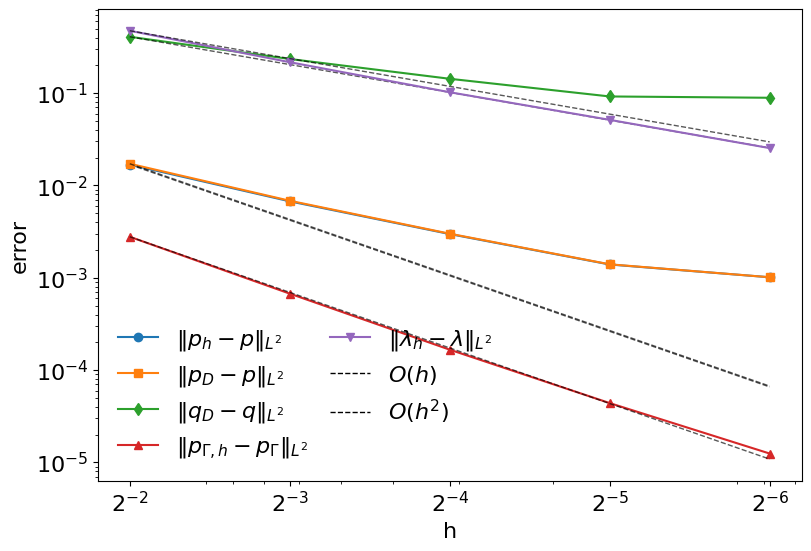

In [6]:
if CONV_PLOT and len(conv_results):
    try:
        from matplotlib.lines import Line2D

        CONV_PLOT_REFS = [r for r in CONV_REFS]
        CONV_BENCHMARK_ORDERS = {
            "p_h": 2,
            "p_D": 2,
            "q_D": 1,
            "p_Gamma": 2,
            "lambda": 1,
        }
        CONV_BENCHMARK_COLOR = "black"

        def selected_convergence_rows(rows, selected_refs):
            if selected_refs is None or selected_refs == "all":
                return list(rows)
            requested = [int(r) for r in selected_refs]
            requested_set = set(requested)
            return [row for row in rows if int(row["ref"]) in requested_set]

        def benchmark_label(order):
            if np.isclose(order, 1.0):
                return r"$O(h)$"
            if np.isclose(order, round(order)):
                return rf"$O(h^{int(round(order))})$"
            return rf"$O(h^{{{order:g}}})$"

        def add_benchmark_line(ax, hs, values, order, color="black", linestyle="--"):
            hs = np.asarray(hs, dtype=float)
            values = np.asarray(values, dtype=float)
            mask = np.isfinite(hs) & np.isfinite(values) & (hs > 0.0) & (values > 0.0)
            if np.count_nonzero(mask) < 2:
                return False
            h_valid = hs[mask]
            v_valid = values[mask]
            h0 = h_valid[0]
            v0 = v_valid[0]
            h_ref = np.array([h_valid.max(), h_valid.min()])
            v_ref = v0 * (h_ref / h0) ** float(order)
            ax.loglog(h_ref, v_ref, color=color, ls=linestyle, lw=1.0, alpha=0.65, label="_nolegend_")
            return True

        plot_rows = selected_convergence_rows(conv_results, CONV_PLOT_REFS)
        refs = np.array([row["ref"] for row in plot_rows], dtype=int)
        hs = np.array([row["h"] for row in plot_rows], dtype=float)
        series = [
            ("p_h", "err_p_cg_l2", r"$\|p_h-p\|_{L^2}$", "o-"),
            ("p_D", "err_p_rec_l2", r"$\|p_D-p\|_{L^2}$", "s-"),
            ("q_D", "err_q_rec", r"$\|q_D-q\|_{L^2}$", "d-"),
            ("p_Gamma", "err_p_gamma_l2", r"$\|p_{\Gamma,h}-p_\Gamma\|_{L^2}$", "^-"),
            ("lambda", "err_lam_h", r"$\|\lambda_h-\lambda\|_{L^2}$", "v-"),
        ]

        fs = 16
        fig, ax = plt.subplots(figsize=(8.0, 5.4), constrained_layout=True)
        orders_used = []
        for name, key, label, style in series:
            vals = np.array([row[key] for row in plot_rows], dtype=float)
            ax.loglog(hs, vals, style, label=label)
            order = CONV_BENCHMARK_ORDERS.get(name, 1)
            if add_benchmark_line(ax, hs, vals, order, color=CONV_BENCHMARK_COLOR):
                orders_used.append(order)

        ref_proxies = [
            Line2D([0], [0], color=CONV_BENCHMARK_COLOR, ls="--", lw=1.0, label=benchmark_label(o))
            for o in sorted(set(orders_used))
        ]
        print(f"Convergence plot refs: {[int(row['ref']) for row in plot_rows]}")
        ax.invert_xaxis()
        ax.set_xticks(hs)
        ax.set_xticklabels([rf"$2^{{-{ref}}}$" for ref in refs])
        ax.set_xlabel("h", fontsize=fs)
        ax.set_ylabel("error", fontsize=fs)
        ax.tick_params(axis="both", which="both", labelsize=fs)
        ax.grid(False)
        handles, labels = ax.get_legend_handles_labels()
        handles += ref_proxies
        labels += [proxy.get_label() for proxy in ref_proxies]
        ax.legend(handles, labels, frameon=False, fontsize=fs, ncol=2, columnspacing=1.0, handlelength=1.8)
        plt.show()
    except Exception as exc:
        print(f"Convergence plot skipped: {exc}")
